# Data Scraping

In [ ]:
!pip install TikTokApi
!playwright install chromium
!apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libdrm2 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libasound2 libgstreamer-gl1.0-0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 9.4 MB/s eta 0:00:00
(node:43984) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
167.3 MiB [] 0% 0.0s167.3 MiB [] 0% 176.9s167.3 MiB [] 0% 535.8s167.3 MiB [] 0% 447.3s167.3 MiB [] 0% 610.6s167.3 MiB [] 0% 540.8s167.3 MiB [] 0% 489.5s167.3 MiB [] 0% 452.3s167.3 MiB [] 0% 422.2s167.3 MiB [] 0% 400.3s167.3 MiB [] 0% 388.2s167.3 MiB [] 0% 371.8s167.3 MiB [] 0% 357.2s167.3 MiB [] 0% 344.6s167.3 MiB [] 0% 333.0s167.3 MiB [] 0% 306.3s167.3 MiB [] 0% 301.2s167.3 MiB [] 0% 283.8s167.3 MiB [] 0% 257.0s167.3 MiB [] 0% 235.9s167.3 MiB [] 0% 225.1s167.3 MiB [] 0% 210.5s167.3 MiB [] 0% 199.7s167.3 MiB [] 0% 188.9s167.3 MiB [] 0% 1

In [ ]:
import asyncio
import pandas as pd
from TikTokApi import TikTokApi

ms_token = "LIyp0ppV-LUx1ScPl7s7nZUCMdCmbjRim1hSwu50g78N1NdC7kMwguXy_8q46oJKp2XQC25jZiAQZn48eQy7uXHXT_lv2-uhWmONXCw079t8SkxtvmIV4Fms5GX7NxOqfoe8ZzQ61wE5VA=="

async def scrape():
    comments = []

    async with TikTokApi() as api:
        await api.create_sessions(
            ms_tokens=[ms_token],
            num_sessions=1,
            sleep_after=3,
            headless=True,
            timeout=60000
        )

        video = api.video(url="https://www.tiktok.com/@officialokezone/video/7627053537217891601")

        try:
            async for comment in video.comments(count=1800):
                comments.append({
                    "username": comment.author.username,
                    "comment": comment.text,
                    "likes": comment.likes_count,
                })
                print(f"[{len(comments)}] {comment.author.username}: {comment.text[:50]}")

                # 💾 Auto-save tiap 100 komentar
                if len(comments) % 100 == 0:
                    pd.DataFrame(comments).to_csv("comments.csv", index=False)
                    print(f"💾 Auto-saved {len(comments)} komentar")

        except Exception as e:
            print(f"⚠️ Berhenti di {len(comments)}: {e}")

        finally:
            # 💾 Paksa save apapun yang terjadi
            pd.DataFrame(comments).to_csv("comments.csv", index=False)
            print(f"✅ Tersimpan: {len(comments)} komentar")

    return comments

comments = await scrape()
df = pd.DataFrame(comments)
print(df.head())

[1] andhika5110: berkat orang yg suka nyari di kali Ciliwung 😊
[2] sandy.fahreza3: tp selain ikan sapu" ada yg lebih penting lg, kebe
[3] araisyafs26_: ih gede gede bangettt
[4] siscayf: Gede bangettt jirrrr
[5] lim_chinxiaa: tidak boleh dimakan ikan jenis itu
[6] paracetamol_190: kang somay panik
[7] mas__ihsan17: maaf ga bisa dimanfaatkan kah, itu ikan
[8] aominedaiki10054: Tebak anggaran yang dipakai
[9] bighero669: [Sticker] kang somay?
[10] cweebluee: salfok sama "DIOR" di atas😭😭🙏🏻
[11] krikillepas83: kurang kerjaan
[12] r15standard: sementara itu di danau toba🗿
[13] apapapapaaa19: pak kalo boleh saran ya, agaknya kurang efektif de
[14] bungki1804: untuk sementara aku stop makan mie ayam
[15] cocomilk217: Segala ciptaan Tuhan pasti memiliki manfaat dan hi
[16] gmzze0: dia juga pengen hidup woi🙏
[17] ajilah905: ikan juga punya perusahaan lohh🥺
[18] breezy_111: Apaaa? Furab?
[19] noni1234t: di Kalimantan kok gak ada ya ikan sapu sapu
[20] umi.nurhayati405: mereka kan juga pingin hid

# Text Classification Analysis

In [ ]:
!pip install transformers torch pandas
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from transformers import pipeline
from datasets import Dataset
from sklearn.metrics import classification_report
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

## Auto Labeling

In [ ]:
# Auto-labeling pakai IndoBERT Sentiment

# Load data komentar
df = pd.read_csv("comments.csv")
print(f"Total data: {len(df)}")
print(df.head())

# Load model sentiment Bahasa Indonesia dari HuggingFace
# Model: ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa
print("\n⏳ Loading model...")
sentiment_pipeline = pipeline(
    "text-classification",
    model="ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa",
    tokenizer="ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa"
)

Total data: 1478
         username                                            comment   likes
0     andhika5110      berkat orang yg suka nyari di kali Ciliwung 😊   69222
1  sandy.fahreza3  tp selain ikan sapu" ada yg lebih penting lg, ...   12206
2    araisyafs26_                              ih gede gede bangettt  138284
3         siscayf                               Gede bangettt jirrrr   44579
4    lim_chinxiaa                 tidak boleh dimakan ikan jenis itu   28331

⏳ Loading model...


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# Prediksi label tiap komentar
def predict_sentiment(text):
    try:
        # Truncate kalau terlalu panjang
        text = str(text)[:512]
        result = sentiment_pipeline(text)[0]
        return result['label'], round(result['score'], 4)
    except Exception as e:
        return "unknown", 0.0

print("\n🔄 Auto-labeling...")
labels = []
scores = []

for i, row in df.iterrows():
    label, score = predict_sentiment(row['comment'])
    labels.append(label)
    scores.append(score)

    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{len(df)}] selesai")

df['sentiment'] = labels
df['confidence'] = scores

# Simpan & cek distribusi
df.to_csv("comments_labeled.csv", index=False)
print("\n Selesai! Saved ke comments_labeled.csv")

print("\n Distribusi Sentiment:")
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\n Contoh hasil:")
print(df[['comment', 'sentiment', 'confidence']].sample(10))


🔄 Auto-labeling...
  [100/1478] selesai
  [200/1478] selesai
  [300/1478] selesai
  [400/1478] selesai
  [500/1478] selesai
  [600/1478] selesai
  [700/1478] selesai
  [800/1478] selesai
  [900/1478] selesai
  [1000/1478] selesai
  [1100/1478] selesai
  [1200/1478] selesai
  [1300/1478] selesai
  [1400/1478] selesai

 Selesai! Saved ke comments_labeled.csv

 Distribusi Sentiment:
sentiment
Negative    632
Neutral     507
Positive    339
Name: count, dtype: int64
sentiment
Negative    42.8%
Neutral     34.3%
Positive    22.9%
Name: proportion, dtype: object

 Contoh hasil:
                                                comment sentiment  confidence
1126                 manfaatkan buat pakan ternak bebek   Neutral      0.9996
663                                  org ciliwung mana😁   Neutral      0.9977
593                     bearti ekosistem sungai berubah  Negative      0.9980
1433                          Itu kan mahal di resto ya  Negative      0.9998
138   sampah masih numpuk, uja

## Fine Tuning

### Filter data confidence tinggi sebagai training data

In [ ]:
# Load hasil labeling sebelumnya
df = pd.read_csv("comments_labeled.csv")

# Pakai hanya data confidence >= 0.90 untuk fine-tuning
df_high_conf = df[df['confidence'] >= 0.90].copy()
print(f"Data confidence tinggi: {len(df_high_conf)} / {len(df)} ({len(df_high_conf)/len(df)*100:.1f}%)")
print(df_high_conf['sentiment'].value_counts())

# Map label ke angka
label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}
df_high_conf['label'] = df_high_conf['sentiment'].map(label2id)

# Split train/val
train_df, val_df = train_test_split(
    df_high_conf[['comment', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=df_high_conf['label']
)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)}")


Data confidence tinggi: 1284 / 1478 (86.9%)
sentiment
Negative    559
Neutral     422
Positive    303
Name: count, dtype: int64

Train: 1027 | Val: 257


### Tokenizer & Dataset

In [ ]:
MODEL_NAME = "ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['comment'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/1027 [00:00<?, ? examples/s]

Map:   0%|          | 0/257 [00:00<?, ? examples/s]

### Load Model & Fine tune

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average='macro')
    }

training_args = TrainingArguments(
    output_dir="./sentiment_finetuned",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=20,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("\n🚀 Mulai fine-tuning...")
trainer.train()

# Evaluasi
print("\n📊 Evaluasi hasil fine-tune:")
results = trainer.evaluate()
print(f"  Accuracy : {results['eval_accuracy']:.4f}")
print(f"  F1 Macro : {results['eval_f1_macro']:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 Mulai fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.606879,0.358268,0.871595,0.864012
2,0.262487,0.318514,0.898833,0.894839
3,0.030587,0.341558,0.929961,0.926673


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


📊 Evaluasi hasil fine-tune:


  Accuracy : 0.9300
  F1 Macro : 0.9267


In [ ]:
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print(classification_report(
    labels, preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.96      0.92      0.94       112
     Neutral       0.89      0.98      0.93        84
    Positive       0.93      0.89      0.91        61

    accuracy                           0.93       257
   macro avg       0.93      0.93      0.93       257
weighted avg       0.93      0.93      0.93       257



### Re-label semua data pakai model baru

In [ ]:
print("\n🔄 Re-labeling semua data pakai model fine-tuned...")
from transformers import pipeline

ft_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

def predict(text):
    try:
        result = ft_pipeline(str(text)[:512])[0]
        return result['label'], round(result['score'], 4)
    except:
        return "unknown", 0.0

df['sentiment_ft'] = None
df['confidence_ft'] = None

for i, row in df.iterrows():
    label, score = predict(row['comment'])
    df.at[i, 'sentiment_ft'] = label
    df.at[i, 'confidence_ft'] = score
    if (i + 1) % 100 == 0:
        print(f"  [{i+1}/{len(df)}]")

df.to_csv("comments_final.csv", index=False)
print("\n✅ Saved ke comments_final.csv")

print("\n📊 Distribusi Sentiment (Fine-tuned):")
print(df['sentiment_ft'].value_counts())
print(df['sentiment_ft'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')



🔄 Re-labeling semua data pakai model fine-tuned...
  [100/1478]
  [200/1478]
  [300/1478]
  [400/1478]
  [500/1478]
  [600/1478]
  [700/1478]
  [800/1478]
  [900/1478]
  [1000/1478]
  [1100/1478]
  [1200/1478]
  [1300/1478]
  [1400/1478]

✅ Saved ke comments_final.csv

📊 Distribusi Sentiment (Fine-tuned):
sentiment_ft
Negative    628
Neutral     520
Positive    330
Name: count, dtype: int64
sentiment_ft
Negative    42.5%
Neutral     35.2%
Positive    22.3%
Name: proportion, dtype: object


# Analisis Lanjutan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import re

df = pd.read_csv("comments_final.csv")

sentiments = ['Negative', 'Neutral', 'Positive']
colors = {'Negative': 'salmon', 'Neutral': 'steelblue', 'Positive': 'mediumseagreen'}
stopwords_id = set([
    # basic
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk',
    'ada', 'tidak', 'ya', 'juga', 'bisa', 'kalo', 'kalau', 'nya', 'aja',
    'sih', 'deh', 'dong', 'udah', 'sudah', 'nih', 'ga', 'gak', 'nggak',
    'yg', 'dgn', 'tp', 'tapi', 'si', 'kak', 'bang', 'pak', 'bu', 'lah',
    'pun', 'kok', 'mau', 'mah', 'terus', 'lebih', 'sangat', 'banget',

    # tambahan dari word cloud
    'aku', 'gw', 'gua', 'gue', 'kita', 'dia', 'mereka',
    'kayak', 'kaya', 'gitu', 'gini', 'jadi', 'biar',
    'bikin', 'buat', 'pas', 'lagi', 'pernah',
    'anjir', 'jir', 'wkwk', 'haha', 'hehe', 'loh', 'kah',
    'bgt', 'banget', 'kan', 'gt', 'gitu', 'gini',
    'aja', 'lah', 'sama', 'apa', 'banyak'
    'furab','furap',

    # Kata topik utama (dominan semua kelas)
    'ikan', 'sapu', 'sapusapu', 'furab',

    # Noise / tidak bermakna
    'tuh', 'klo', 'kak', 'tau', 'liat', 'gak', 'gk',
    'emang', 'sampe', 'gimana', 'disitu', 'lain',
    'dulu', 'harus', 'masih', 'punya', 'kali', 'aja',
    'juga', 'bisa', 'nih', 'sih', 'deh', 'yg', 'nya',

    # Singkatan tidak bermakna
    'dr', 'tp', 'krn', 'dgn', 'bnyk', 'dpt', 'tdk',

    # Dari neutral yang tidak informatif
    'sticker',  # mungkin nama produk/meme
    'cleaning', 'pakan', 'turap',
])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|@\S+|#\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()

## Distribusi Sentiment

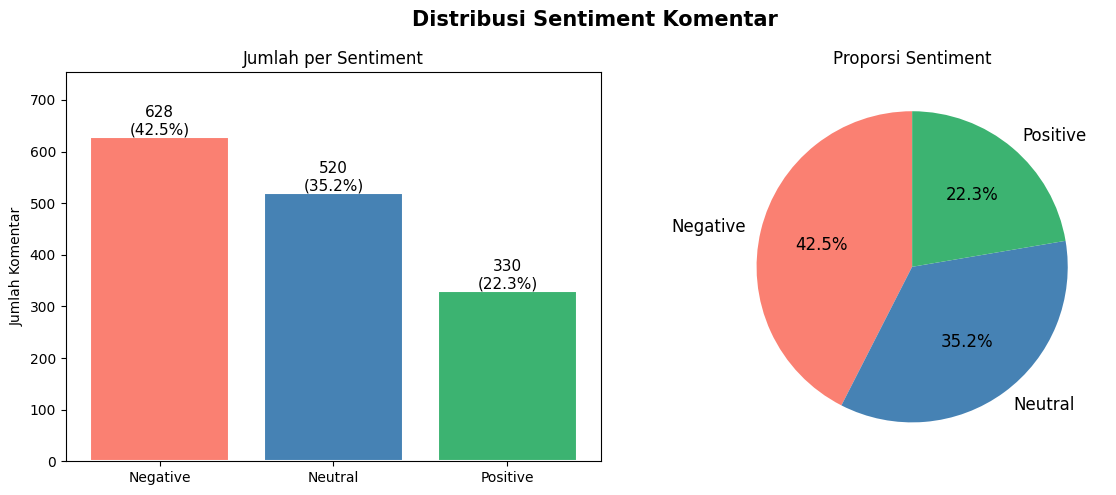

In [ ]:
counts = df['sentiment_ft'].value_counts()[sentiments]
pct = counts / counts.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Sentiment Komentar', fontsize=15, fontweight='bold')

# Bar chart
bars = ax1.bar(sentiments, counts, color=[colors[s] for s in sentiments], edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Jumlah Komentar')
ax1.set_title('Jumlah per Sentiment')
for bar, count, p in zip(bars, counts, pct):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({p:.1f}%)', ha='center', fontsize=11)
ax1.set_ylim(0, max(counts) * 1.2)

# Pie chart
ax2.pie(counts, labels=sentiments, autopct='%1.1f%%',
        colors=[colors[s] for s in sentiments],
        startangle=90, textprops={'fontsize': 12})
ax2.set_title('Proporsi Sentiment')

plt.tight_layout()
plt.savefig('01_distribusi_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## Word Cloud per Sentiment

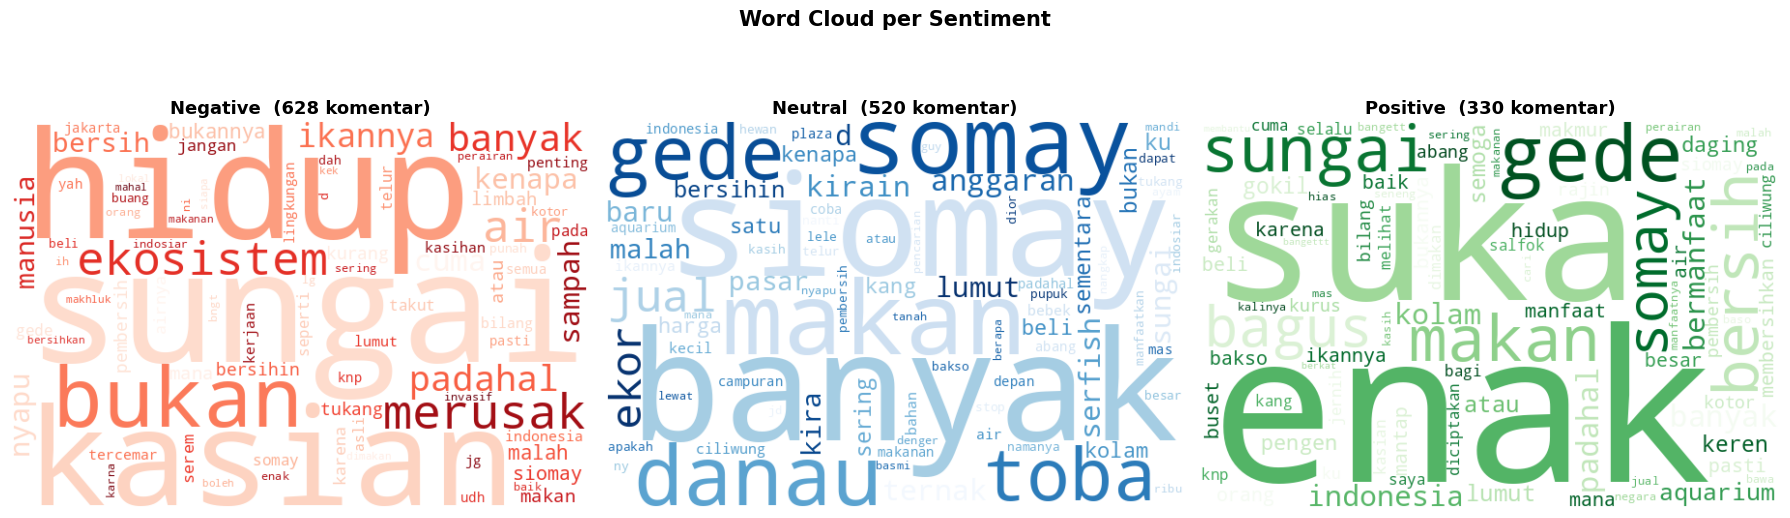

In [ ]:
wc_colors = {'Negative': 'Reds', 'Neutral': 'Blues', 'Positive': 'Greens'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Word Cloud per Sentiment', fontsize=15, fontweight='bold')

for ax, sentiment in zip(axes, sentiments):
    subset = df[df['sentiment_ft'] == sentiment]['comment']
    text = ' '.join(subset.apply(clean_text))

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=wc_colors[sentiment],
        stopwords=stopwords_id,
        max_words=80,
        collocations=False
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment}  ({len(subset)} komentar)', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('02_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## Top 15 Kata per Sentiment

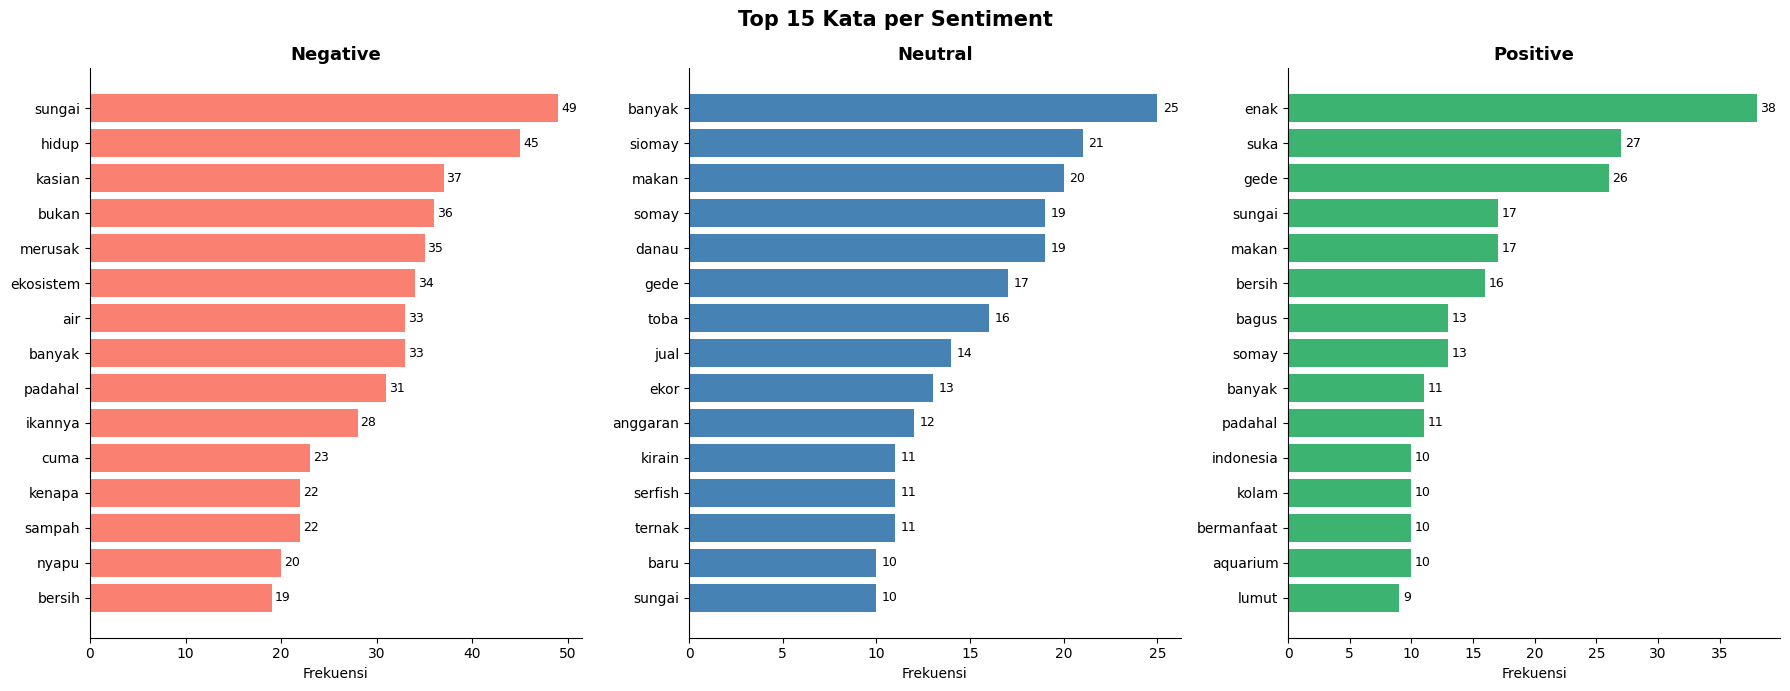

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Top 15 Kata per Sentiment', fontsize=15, fontweight='bold')

for ax, sentiment in zip(axes, sentiments):
    subset = df[df['sentiment_ft'] == sentiment]['comment']
    all_words = []
    for comment in subset:
        words = clean_text(comment).split()
        words = [w for w in words if w not in stopwords_id and len(w) > 2]
        all_words.extend(words)

    top15 = Counter(all_words).most_common(15)
    words_list, counts_list = zip(*top15)

    bars = ax.barh(words_list[::-1], counts_list[::-1], color=colors[sentiment])
    ax.set_title(f'{sentiment}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    for bar, count in zip(bars, counts_list[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('03_topwords.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix

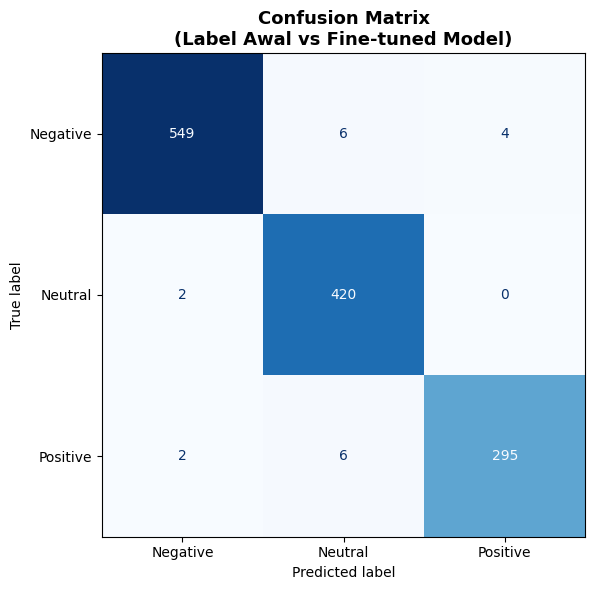

In [ ]:
# Pakai data yang punya label asli (confidence >= 0.90)
df_eval = df[df['confidence'] >= 0.90].copy()

# Confusion matrix: sentiment awal (label asli) vs hasil fine-tune
cm = confusion_matrix(df_eval['sentiment'], df_eval['sentiment_ft'], labels=sentiments)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sentiments)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix\n(Label Awal vs Fine-tuned Model)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Distribusi Confidence Score

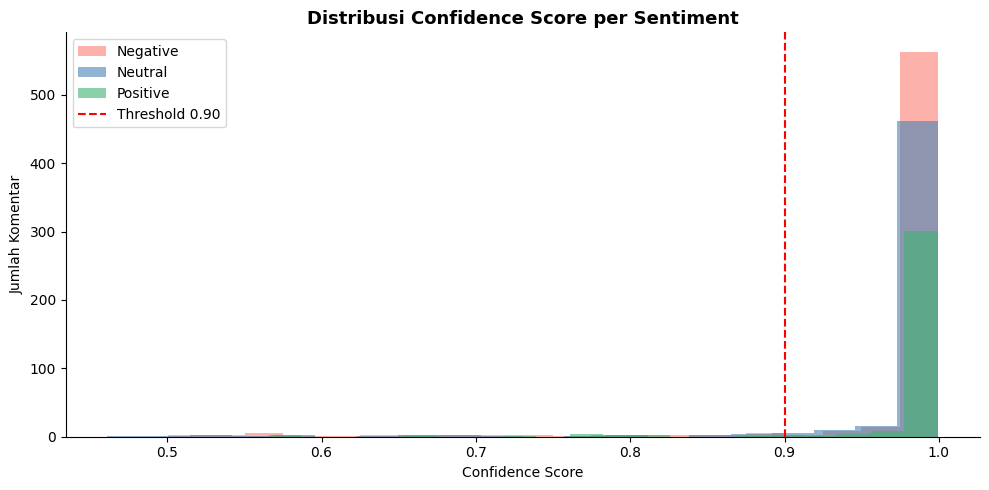

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for sentiment in sentiments:
    subset = df[df['sentiment_ft'] == sentiment]['confidence_ft']
    ax.hist(subset, bins=20, alpha=0.6, label=sentiment, color=colors[sentiment])

ax.axvline(x=0.90, color='red', linestyle='--', linewidth=1.5, label='Threshold 0.90')
ax.set_title('Distribusi Confidence Score per Sentiment', fontsize=13, fontweight='bold')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Jumlah Komentar')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('05_confidence_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Lihat distribusi confidence
print(df['confidence_ft'].describe())

# Komentar yang "ragu-ragu" (model tidak yakin)
df_ragu = df[df['confidence_ft'] < 0.70]
print(f"Komentar ambigus: {len(df_ragu)} ({len(df_ragu)/len(df)*100:.1f}%)")
print(df_ragu[['comment', 'sentiment_ft', 'confidence_ft']].sample(10))

count    1478.000000
mean        0.980149
std         0.070072
min         0.461100
25%         0.997100
50%         0.999000
75%         0.999400
max         0.999700
Name: confidence_ft, dtype: float64
Komentar ambigus: 36 (2.4%)
                                                comment sentiment_ft  \
1467                              ikan cleaning service      Neutral   
511   mungkin dia punya bakat terpendam, jadi blum a...     Negative   
953   Ikan sapu-sapu (\(Pterygoplichthys\) \(spp.\))...     Negative   
1160                              ikan cleaning service      Neutral   
580   Ikan sapu-sapu berbahaya karena berpotensi men...     Negative   
1332  ikan sapu 2 hanya tinggal di di tempat yang ko...     Negative   
714   yang harus di bersihkan bersamaan itu semua pa...     Negative   
503                       ikan sapu2 nya jadi tersangka     Negative   
276   [Sticker] yang Hama Bukan ikan. tapi Pemerinta...      Neutral   
597                 aku mah malah salpok k tulis

# Topic Modelling

In [ ]:
!pip install gensim pyLDAvis -q

import gensim
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Ambil komentar per sentimen
for sentiment in ['Negative', 'Neutral', 'Positive']:
    subset = df[df['sentiment_ft'] == sentiment]['comment']

    # Tokenize & bersihkan
    texts = []
    for comment in subset:
        words = clean_text(comment).split()
        words = [w for w in words if w not in stopwords_id and len(w) > 2]
        texts.append(words)

    # Buat dictionary & corpus
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Train LDA
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=3,       # 3 topik per sentimen
        random_state=42,
        passes=10
    )

    print(f"\n=== Topik dalam komentar {sentiment} ===")
    for idx, topic in lda_model.print_topics(num_words=5):
        print(f"Topik {idx+1}: {topic}")


=== Topik dalam komentar Negative ===
Topik 1: 0.016*"padahal" + 0.013*"nyapu" + 0.011*"merusak" + 0.009*"kenapa" + 0.009*"cuma"
Topik 2: 0.013*"bukan" + 0.011*"ikannya" + 0.009*"sampah" + 0.007*"banyak" + 0.006*"sungai"
Topik 3: 0.018*"kasian" + 0.016*"hidup" + 0.015*"sungai" + 0.010*"ekosistem" + 0.009*"air"

=== Topik dalam komentar Neutral ===
Topik 1: 0.016*"makan" + 0.009*"somay" + 0.008*"ciliwung" + 0.008*"bahan" + 0.007*"sering"
Topik 2: 0.023*"siomay" + 0.017*"gede" + 0.011*"ternak" + 0.011*"jual" + 0.010*"lumut"
Topik 3: 0.020*"danau" + 0.020*"banyak" + 0.017*"toba" + 0.013*"anggaran" + 0.010*"serfish"

=== Topik dalam komentar Positive ===
Topik 1: 0.032*"enak" + 0.024*"suka" + 0.013*"aquarium" + 0.012*"makan" + 0.012*"bersih"
Topik 2: 0.037*"gede" + 0.013*"banyak" + 0.012*"sungai" + 0.011*"enak" + 0.010*"somay"
Topik 3: 0.013*"gokil" + 0.012*"lumut" + 0.012*"pengen" + 0.012*"bagus" + 0.010*"mantap"
